In [1]:
import os
import re
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.utils import class_weight
sns.set(style="whitegrid")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


## Налаштування параметрів

Задаємо шляхи до файлів, розмірність Word2Vec векторів, параметри PCA та розмір тестової вибірки.


In [2]:
TRAIN_PATH = "Corona_NLP_train.csv"
TEST_PATH = "Corona_NLP_test.csv"
SINGLE_PATH = "Crona_NLP.csv"
TEXT_COL_CANDIDATES = ["OriginalTweet", "Original Tweet", "OriginalTweet_text", "text", "tweet", "tweet_text"]
LABEL_COL_CANDIDATES = ["Sentiment", "Label", "label", "sentiment"]

RANDOM_STATE = 42
TEST_SIZE = 0.2
W2V_SIZE = 100
W2V_WINDOW = 5
W2V_MIN_COUNT = 2
W2V_EPOCHS = 10
PCA_COMPONENTS_LIST = [None, 50, 100, 200]

nltk.download("punkt")
nltk.download("stopwords")
STOPWORDS = set(stopwords.words("english"))




[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Функції для підготовки тексту

Тут реалізовані функції:
- clean_text: очищення тексту
- tokenize: токенізація та видалення стоп-слів
- tweet_vector: середнє значення векторів слів
- find_column: пошук колонки за можливими іменами
- standardize_columns: нормалізація назв колонок на "text" та "label"


In [3]:
def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"@\w+", " ", s)
    s = re.sub(r"#", " ", s)
    s = re.sub(r"[^a-zA-Z0-9\s']", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def tokenize(text: str):
    toks = word_tokenize(str(text))
    toks = [t for t in toks if t.isalpha() and t not in STOPWORDS and len(t) > 1]
    return toks

def tweet_vector(tokens, model, vector_size):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if len(vecs) == 0:
        return np.zeros(vector_size, dtype=float)
    return np.mean(vecs, axis=0)

def find_column(df_cols, candidates):
    for c in candidates:
        if c in df_cols:
            return c
    return None

def standardize_columns(df):
    cols = df.columns
    txt_col = find_column(cols, TEXT_COL_CANDIDATES)
    lbl_col = find_column(cols, LABEL_COL_CANDIDATES)
    if txt_col is None or lbl_col is None:
        txt_guess, lbl_guess = None, None
        for c in cols:
            cl = c.lower()
            if txt_guess is None and ("tweet" in cl or "text" in cl):
                txt_guess = c
            if lbl_guess is None and ("sent" in cl or "label" in cl or "target" in cl):
                lbl_guess = c
        if txt_guess is None or lbl_guess is None:
            raise ValueError(f"Не вдалося знайти текстову/label колонку. Columns: {list(cols)}")
        txt_col, lbl_col = txt_guess, lbl_guess
    return df[[txt_col, lbl_col]].dropna().rename(columns={txt_col: "text", lbl_col: "label"})


## Завантаження даних

Читаємо train/test CSV якщо вони існують, інакше робимо split із єдиного файлу.


In [4]:
if os.path.exists(TRAIN_PATH) and os.path.exists(TEST_PATH):
    df_train = pd.read_csv(TRAIN_PATH, encoding="latin1")
    df_test  = pd.read_csv(TEST_PATH, encoding="latin1")
else:
    if os.path.exists(SINGLE_PATH):
        df_all = pd.read_csv(SINGLE_PATH, encoding="utf-8", errors="replace")
        df_all = standardize_columns(df_all)
        df_train, df_test = train_test_split(df_all, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df_all["label"])
    else:
        raise FileNotFoundError("Не знайдено вхідних CSV файлів.")

df_train = standardize_columns(df_train)
df_test = standardize_columns(df_test)

print("Train size:", len(df_train))
print("Test size:", len(df_test))


Train size: 41157
Test size: 3798


## Мапінг лейблів на три класи: Positive, Negative, Other


In [5]:
def map_label_to_three(x):
    s = str(x).strip().lower()
    if s in ("positive", "pos", "p"):
        return "Positive"
    if s in ("negative", "neg", "n"):
        return "Negative"
    if "positive" in s:
        return "Positive"
    if "negative" in s:
        return "Negative"
    if s in ("neutral", "neut", "other", "mixed", "irrelevant"):
        return "Other"
    if s.isdigit():
        v = int(s)
        return "Negative" if v==0 else ("Positive" if v==2 else "Other")
    return "Other"

df_train["label3"] = df_train["label"].apply(map_label_to_three)
df_test["label3"] = df_test["label"].apply(map_label_to_three)

print("Label distribution (train):")
print(df_train["label3"].value_counts())


Label distribution (train):
label3
Positive    18046
Negative    15398
Other        7713
Name: count, dtype: int64


## Чистка та токенізація текстів


In [6]:
df_train["clean"] = df_train["text"].apply(clean_text)
df_train["tokens"] = df_train["clean"].apply(tokenize)
df_test["clean"] = df_test["text"].apply(clean_text)
df_test["tokens"] = df_test["clean"].apply(tokenize)

df_train = df_train[df_train["tokens"].map(len) > 0].reset_index(drop=True)
df_test = df_test[df_test["tokens"].map(len) > 0].reset_index(drop=True)
print("After token filtering - train:", len(df_train), " test:", len(df_test))


After token filtering - train: 41123  test: 3796


## Навчання Word2Vec на всьому корпусі


In [7]:
sentences = list(df_train["tokens"]) + list(df_test["tokens"])
w2v_model = Word2Vec(sentences=sentences, vector_size=W2V_SIZE, window=W2V_WINDOW,
                     min_count=W2V_MIN_COUNT, workers=4, epochs=W2V_EPOCHS, seed=RANDOM_STATE)
joblib.dump(w2v_model, "w2v_model.joblib")
print("Word2Vec trained. vocab size:", len(w2v_model.wv.index_to_key))


Word2Vec trained. vocab size: 20994


## Побудова матриць ознак


In [8]:
X_train = np.vstack(df_train["tokens"].apply(lambda t: tweet_vector(t, w2v_model, W2V_SIZE)).values)
X_test = np.vstack(df_test["tokens"].apply(lambda t: tweet_vector(t, w2v_model, W2V_SIZE)).values)
y_train_raw = df_train["label3"].values
y_test_raw = df_test["label3"].values

le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)
print("Classes:", dict(enumerate(le.classes_)))


Classes: {0: 'Negative', 1: 'Other', 2: 'Positive'}


## Навчання моделей та оцінка з PCA



Experiment: NoPCA

Training model: LogisticRegression with NoPCA


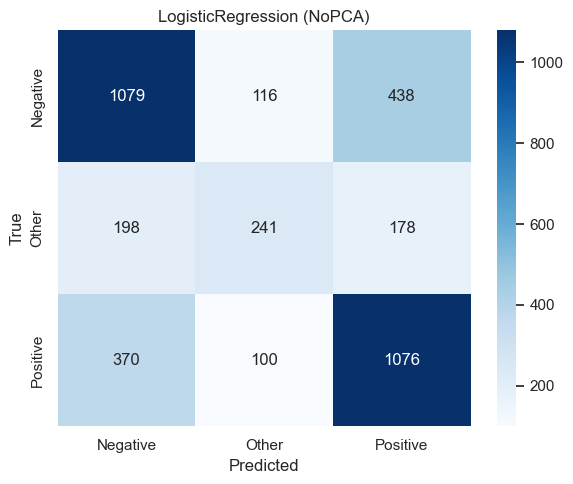

Saved CM: cm_LogisticRegression_NoPCA.png
Model LogisticRegression trained & saved: pipeline_LogisticRegression_NoPCA.joblib; accuracy=0.6312
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.655130540376442, 'recall': 0.6607470912431108, 'f1-score': 0.6579268292682927, 'support': 1633.0}, 'Other': {'precision': 0.5273522975929978, 'recall': 0.3905996758508914, 'f1-score': 0.44878957169459965, 'support': 617.0}, 'Positive': {'precision': 0.6359338061465721, 'recall': 0.6959896507115135, 'f1-score': 0.6646077825818406, 'support': 1546.0}, 'accuracy': 0.631190727081138, 'macro avg': {'precision': 0.606138881372004, 'recall': 0.5824454726018385, 'f1-score': 0.590441394514911, 'support': 3796.0}, 'weighted avg': {'precision': 0.6265432572055348, 'recall': 0.631190727081138, 'f1-score': 0.626654718072238, 'support': 3796.0}}

Training model: LinearSVM with NoPCA
[LibLinear]

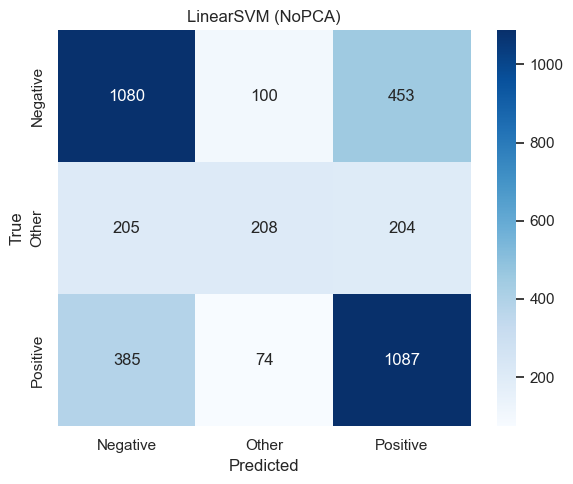

Saved CM: cm_LinearSVM_NoPCA.png
Model LinearSVM trained & saved: pipeline_LinearSVM_NoPCA.joblib; accuracy=0.6257
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.6467065868263473, 'recall': 0.6613594611145132, 'f1-score': 0.6539509536784741, 'support': 1633.0}, 'Other': {'precision': 0.5445026178010471, 'recall': 0.3371150729335494, 'f1-score': 0.4164164164164164, 'support': 617.0}, 'Positive': {'precision': 0.6232798165137615, 'recall': 0.703104786545925, 'f1-score': 0.660790273556231, 'support': 1546.0}, 'accuracy': 0.6256585879873551, 'macro avg': {'precision': 0.6048296737137187, 'recall': 0.5671931068646625, 'f1-score': 0.5770525478837072, 'support': 3796.0}, 'weighted avg': {'precision': 0.6205533634881313, 'recall': 0.6256585879873551, 'f1-score': 0.6181276604857245, 'support': 3796.0}}

Training model: RandomForest with NoPCA


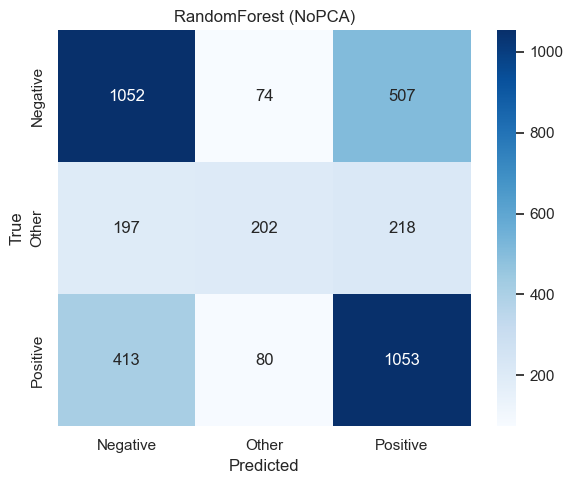

Saved CM: cm_RandomForest_NoPCA.png
Model RandomForest trained & saved: pipeline_RandomForest_NoPCA.joblib; accuracy=0.6077
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.6329723225030084, 'recall': 0.6442131047152481, 'f1-score': 0.6385432473444613, 'support': 1633.0}, 'Other': {'precision': 0.5674157303370787, 'recall': 0.3273905996758509, 'f1-score': 0.41521068859198357, 'support': 617.0}, 'Positive': {'precision': 0.5922384701912261, 'recall': 0.6811125485122898, 'f1-score': 0.6335740072202166, 'support': 1546.0}, 'accuracy': 0.6077449947312961, 'macro avg': {'precision': 0.5975421743437711, 'recall': 0.5509054176344629, 'f1-score': 0.5624426477188872, 'support': 3796.0}, 'weighted avg': {'precision': 0.6057270767073303, 'recall': 0.6077449947312961, 'f1-score': 0.6002190550414157, 'support': 3796.0}}

Training model: GaussianNB with NoPCA


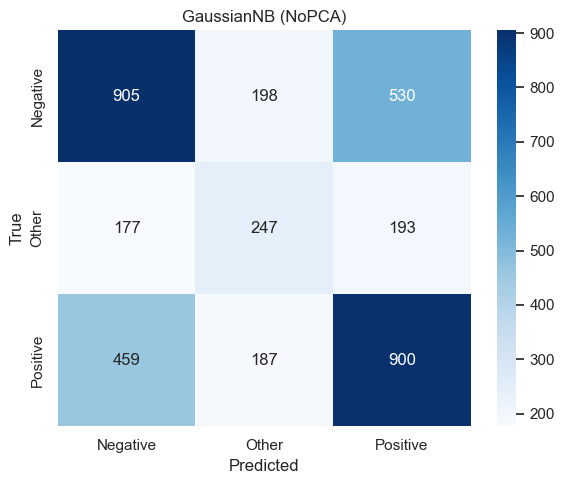

Saved CM: cm_GaussianNB_NoPCA.png
Model GaussianNB trained & saved: pipeline_GaussianNB_NoPCA.joblib; accuracy=0.5406
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.5872809863724854, 'recall': 0.554194733619106, 'f1-score': 0.5702583490863264, 'support': 1633.0}, 'Other': {'precision': 0.39082278481012656, 'recall': 0.40032414910858993, 'f1-score': 0.3955164131305044, 'support': 617.0}, 'Positive': {'precision': 0.5545286506469501, 'recall': 0.5821474773609314, 'f1-score': 0.5680025244556642, 'support': 1546.0}, 'accuracy': 0.5405690200210748, 'macro avg': {'precision': 0.5108774739431873, 'recall': 0.5122221200295424, 'f1-score': 0.5112590955574984, 'support': 3796.0}, 'weighted avg': {'precision': 0.542009695172366, 'recall': 0.5405690200210748, 'f1-score': 0.5409371479894493, 'support': 3796.0}}

Experiment: PCA_50

Training model: LogisticRegression with PCA_50


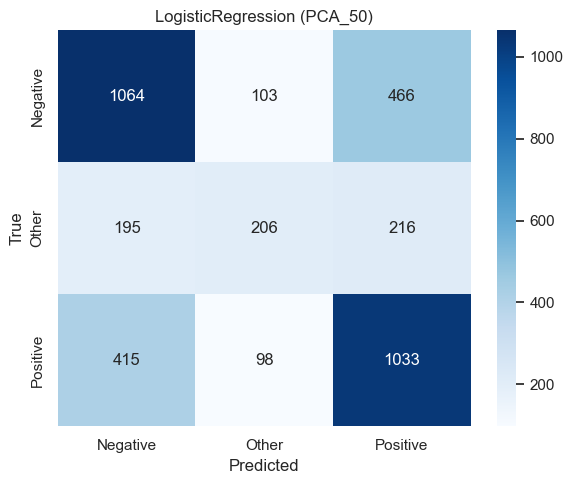

Saved CM: cm_LogisticRegression_PCA_50.png
Model LogisticRegression trained & saved: pipeline_LogisticRegression_PCA_50.joblib; accuracy=0.6067
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.6356033452807647, 'recall': 0.6515615431720759, 'f1-score': 0.6434835198064711, 'support': 1633.0}, 'Other': {'precision': 0.5061425061425061, 'recall': 0.3338735818476499, 'f1-score': 0.40234375, 'support': 617.0}, 'Positive': {'precision': 0.602332361516035, 'recall': 0.6681759379042691, 'f1-score': 0.6335479914136768, 'support': 1546.0}, 'accuracy': 0.6066912539515279, 'macro avg': {'precision': 0.581359404313102, 'recall': 0.5512036876413317, 'f1-score': 0.5597917537400493, 'support': 3796.0}, 'weighted avg': {'precision': 0.6010105426863027, 'recall': 0.6066912539515279, 'f1-score': 0.6002423277975532, 'support': 3796.0}}

Training model: LinearSVM with PCA_50
[LibLinear]

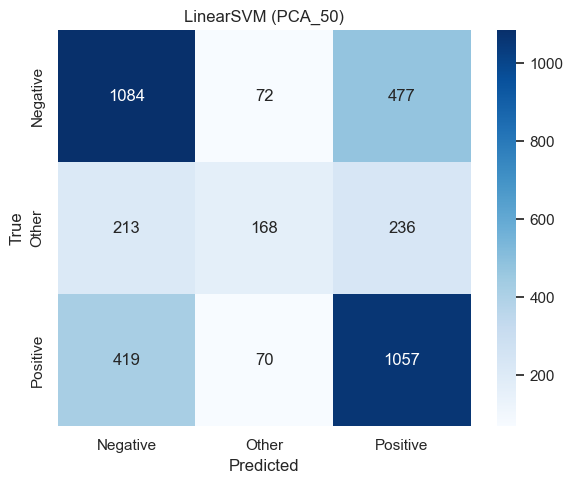

Saved CM: cm_LinearSVM_PCA_50.png
Model LinearSVM trained & saved: pipeline_LinearSVM_PCA_50.joblib; accuracy=0.6083
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.6317016317016317, 'recall': 0.6638089406001225, 'f1-score': 0.6473574201254105, 'support': 1633.0}, 'Other': {'precision': 0.5419354838709678, 'recall': 0.27228525121555913, 'f1-score': 0.36245954692556637, 'support': 617.0}, 'Positive': {'precision': 0.5971751412429378, 'recall': 0.6836998706338939, 'f1-score': 0.6375150784077201, 'support': 1546.0}, 'accuracy': 0.6082718651211801, 'macro avg': {'precision': 0.5902707522718458, 'recall': 0.5399313541498585, 'f1-score': 0.5491106818195657, 'support': 3796.0}, 'weighted avg': {'precision': 0.6030494537615211, 'recall': 0.6082718651211801, 'f1-score': 0.5970417594141741, 'support': 3796.0}}

Training model: RandomForest with PCA_50


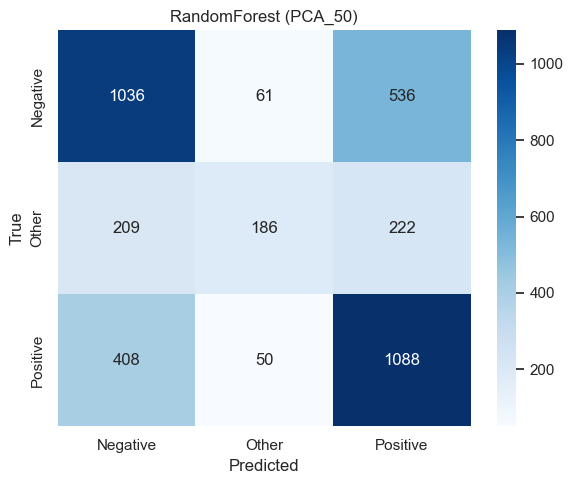

Saved CM: cm_RandomForest_PCA_50.png
Model RandomForest trained & saved: pipeline_RandomForest_PCA_50.joblib; accuracy=0.6085
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.6267392619479734, 'recall': 0.6344151867728107, 'f1-score': 0.6305538648813147, 'support': 1633.0}, 'Other': {'precision': 0.6262626262626263, 'recall': 0.3014586709886548, 'f1-score': 0.40700218818380746, 'support': 617.0}, 'Positive': {'precision': 0.5893824485373781, 'recall': 0.703751617076326, 'f1-score': 0.6415094339622641, 'support': 1546.0}, 'accuracy': 0.6085353003161222, 'macro avg': {'precision': 0.6141281122493258, 'recall': 0.5465418249459305, 'f1-score': 0.5596884956757955, 'support': 3796.0}, 'weighted avg': {'precision': 0.6114474501063929, 'recall': 0.6085353003161222, 'f1-score': 0.5986797672197725, 'support': 3796.0}}

Training model: GaussianNB with PCA_50


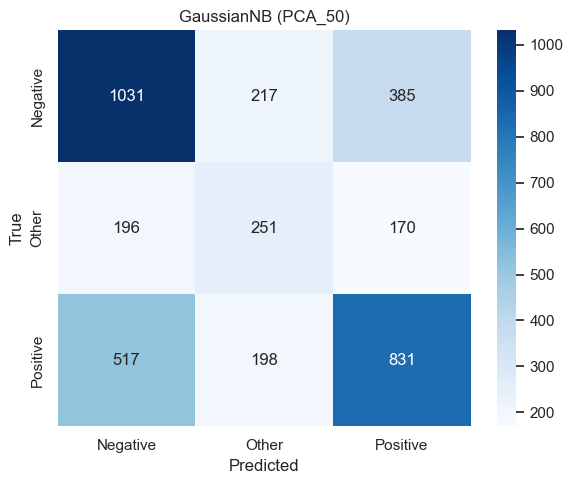

Saved CM: cm_GaussianNB_PCA_50.png
Model GaussianNB trained & saved: pipeline_GaussianNB_PCA_50.joblib; accuracy=0.5566
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.5911697247706422, 'recall': 0.6313533374157991, 'f1-score': 0.6106011252591057, 'support': 1633.0}, 'Other': {'precision': 0.3768768768768769, 'recall': 0.406807131280389, 'f1-score': 0.3912704598597038, 'support': 617.0}, 'Positive': {'precision': 0.5995670995670995, 'recall': 0.53751617076326, 'f1-score': 0.5668485675306958, 'support': 1546.0}, 'accuracy': 0.5566385669125395, 'macro avg': {'precision': 0.5225379004048728, 'recall': 0.5252255464864827, 'f1-score': 0.5229067175498351, 'support': 3796.0}, 'weighted avg': {'precision': 0.559758674793, 'recall': 0.5566385669125395, 'f1-score': 0.5571320855331962, 'support': 3796.0}}

Experiment: PCA_100

Training model: LogisticRegression with PCA_100


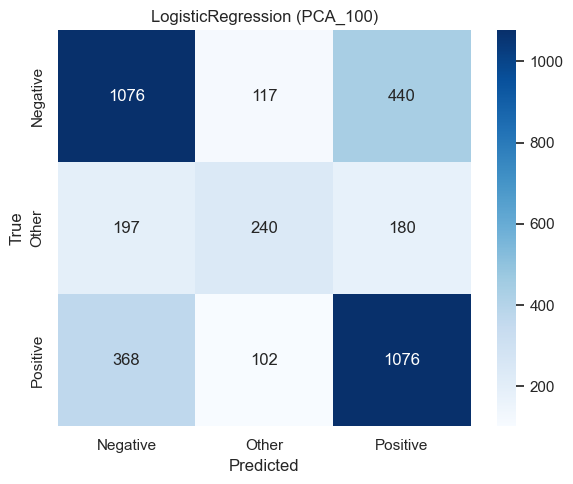

Saved CM: cm_LogisticRegression_PCA_100.png
Model LogisticRegression trained & saved: pipeline_LogisticRegression_PCA_100.joblib; accuracy=0.6301
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.65569774527727, 'recall': 0.6589099816289039, 'f1-score': 0.657299938912645, 'support': 1633.0}, 'Other': {'precision': 0.5228758169934641, 'recall': 0.3889789303079417, 'f1-score': 0.44609665427509293, 'support': 617.0}, 'Positive': {'precision': 0.6344339622641509, 'recall': 0.6959896507115135, 'f1-score': 0.6637877853177051, 'support': 1546.0}, 'accuracy': 0.6301369863013698, 'macro avg': {'precision': 0.6043358415116283, 'recall': 0.5812928542161196, 'f1-score': 0.5890614595018144, 'support': 3796.0}, 'weighted avg': {'precision': 0.6254488152747962, 'recall': 0.6301369863013698, 'f1-score': 0.6256133698717739, 'support': 3796.0}}

Training model: LinearSVM with PCA_100
[LibLinear]

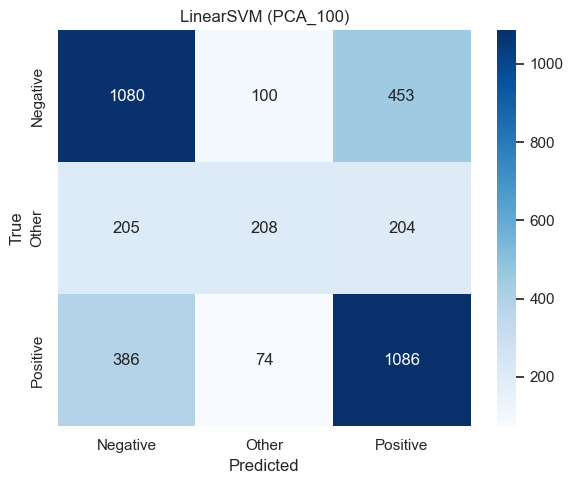

Saved CM: cm_LinearSVM_PCA_100.png
Model LinearSVM trained & saved: pipeline_LinearSVM_PCA_100.joblib; accuracy=0.6254
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.6463195691202872, 'recall': 0.6613594611145132, 'f1-score': 0.6537530266343826, 'support': 1633.0}, 'Other': {'precision': 0.5445026178010471, 'recall': 0.3371150729335494, 'f1-score': 0.4164164164164164, 'support': 617.0}, 'Positive': {'precision': 0.6230636833046471, 'recall': 0.702457956015524, 'f1-score': 0.6603830951657038, 'support': 1546.0}, 'accuracy': 0.6253951527924131, 'macro avg': {'precision': 0.6046286234086605, 'recall': 0.5669774966878621, 'f1-score': 0.5768508460721676, 'support': 3796.0}, 'weighted avg': {'precision': 0.6202988477201421, 'recall': 0.6253951527924131, 'f1-score': 0.617876682441795, 'support': 3796.0}}

Training model: RandomForest with PCA_100


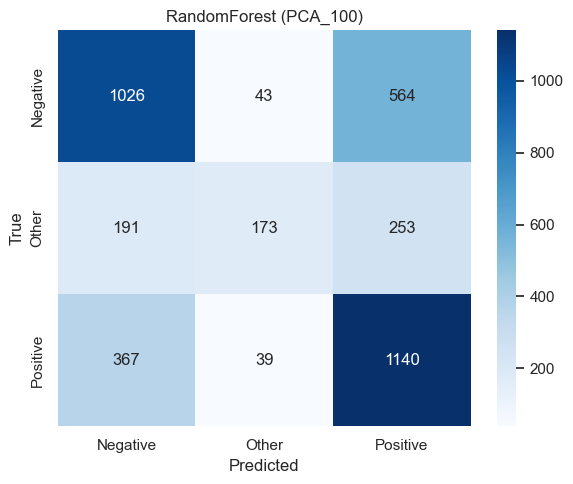

Saved CM: cm_RandomForest_PCA_100.png
Model RandomForest trained & saved: pipeline_RandomForest_PCA_100.joblib; accuracy=0.6162
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.6477272727272727, 'recall': 0.6282914880587875, 'f1-score': 0.6378613615169413, 'support': 1633.0}, 'Other': {'precision': 0.6784313725490196, 'recall': 0.28038897893030795, 'f1-score': 0.3967889908256881, 'support': 617.0}, 'Positive': {'precision': 0.5825242718446602, 'recall': 0.7373868046571799, 'f1-score': 0.650870682272338, 'support': 1546.0}, 'accuracy': 0.6161749209694415, 'macro avg': {'precision': 0.6362276390403175, 'recall': 0.5486890905487585, 'f1-score': 0.5618403448716558, 'support': 3796.0}, 'weighted avg': {'precision': 0.6261626231554863, 'recall': 0.6161749209694415, 'f1-score': 0.6039758918571257, 'support': 3796.0}}

Training model: GaussianNB with PCA_100


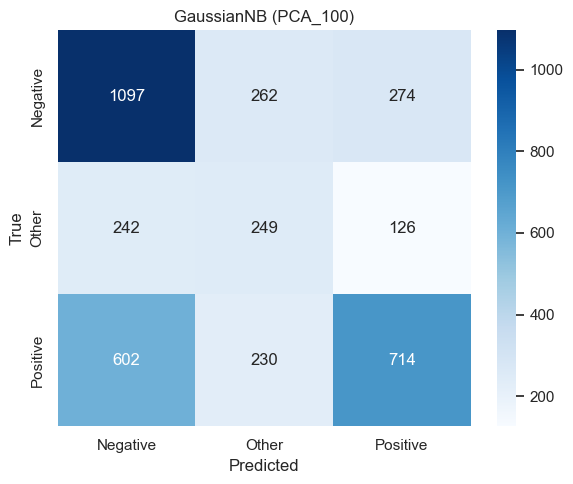

Saved CM: cm_GaussianNB_PCA_100.png
Model GaussianNB trained & saved: pipeline_GaussianNB_PCA_100.joblib; accuracy=0.5427
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.5651725914477074, 'recall': 0.6717697489283527, 'f1-score': 0.6138780078343593, 'support': 1633.0}, 'Other': {'precision': 0.3360323886639676, 'recall': 0.4035656401944895, 'f1-score': 0.36671575846833576, 'support': 617.0}, 'Positive': {'precision': 0.6409335727109515, 'recall': 0.46183699870633893, 'f1-score': 0.5368421052631579, 'support': 1546.0}, 'accuracy': 0.5426765015806112, 'macro avg': {'precision': 0.5140461842742089, 'recall': 0.5123907959430604, 'f1-score': 0.5058119571886177, 'support': 3796.0}, 'weighted avg': {'precision': 0.558783490266308, 'recall': 0.5426765015806112, 'f1-score': 0.5423299010814843, 'support': 3796.0}}

Experiment: PCA_200

Training model: LogisticRegression with PCA_200


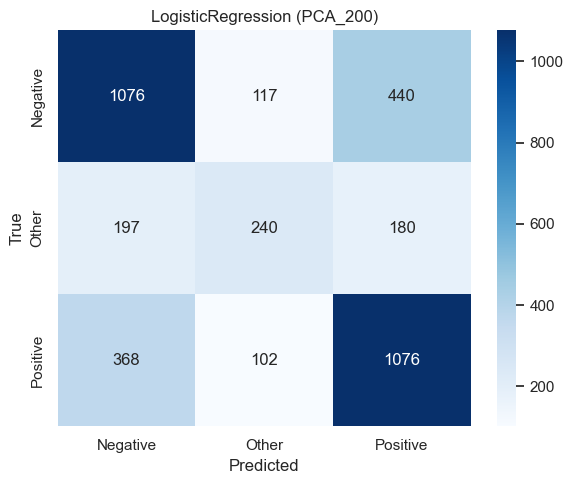

Saved CM: cm_LogisticRegression_PCA_200.png
Model LogisticRegression trained & saved: pipeline_LogisticRegression_PCA_200.joblib; accuracy=0.6301
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.65569774527727, 'recall': 0.6589099816289039, 'f1-score': 0.657299938912645, 'support': 1633.0}, 'Other': {'precision': 0.5228758169934641, 'recall': 0.3889789303079417, 'f1-score': 0.44609665427509293, 'support': 617.0}, 'Positive': {'precision': 0.6344339622641509, 'recall': 0.6959896507115135, 'f1-score': 0.6637877853177051, 'support': 1546.0}, 'accuracy': 0.6301369863013698, 'macro avg': {'precision': 0.6043358415116283, 'recall': 0.5812928542161196, 'f1-score': 0.5890614595018144, 'support': 3796.0}, 'weighted avg': {'precision': 0.6254488152747962, 'recall': 0.6301369863013698, 'f1-score': 0.6256133698717739, 'support': 3796.0}}

Training model: LinearSVM with PCA_200
[LibLinear]

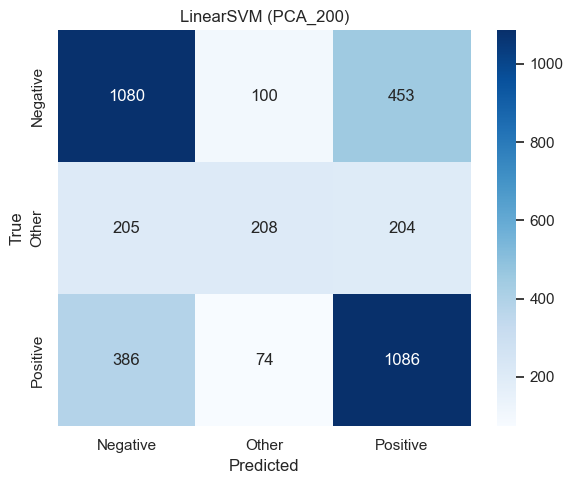

Saved CM: cm_LinearSVM_PCA_200.png
Model LinearSVM trained & saved: pipeline_LinearSVM_PCA_200.joblib; accuracy=0.6254
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.6463195691202872, 'recall': 0.6613594611145132, 'f1-score': 0.6537530266343826, 'support': 1633.0}, 'Other': {'precision': 0.5445026178010471, 'recall': 0.3371150729335494, 'f1-score': 0.4164164164164164, 'support': 617.0}, 'Positive': {'precision': 0.6230636833046471, 'recall': 0.702457956015524, 'f1-score': 0.6603830951657038, 'support': 1546.0}, 'accuracy': 0.6253951527924131, 'macro avg': {'precision': 0.6046286234086605, 'recall': 0.5669774966878621, 'f1-score': 0.5768508460721676, 'support': 3796.0}, 'weighted avg': {'precision': 0.6202988477201421, 'recall': 0.6253951527924131, 'f1-score': 0.617876682441795, 'support': 3796.0}}

Training model: RandomForest with PCA_200


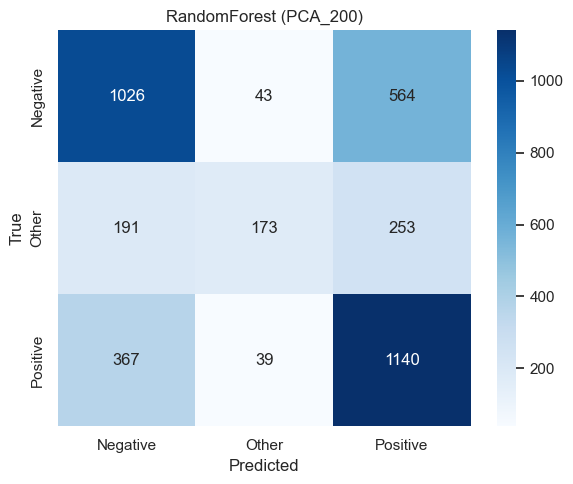

Saved CM: cm_RandomForest_PCA_200.png
Model RandomForest trained & saved: pipeline_RandomForest_PCA_200.joblib; accuracy=0.6162
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.6477272727272727, 'recall': 0.6282914880587875, 'f1-score': 0.6378613615169413, 'support': 1633.0}, 'Other': {'precision': 0.6784313725490196, 'recall': 0.28038897893030795, 'f1-score': 0.3967889908256881, 'support': 617.0}, 'Positive': {'precision': 0.5825242718446602, 'recall': 0.7373868046571799, 'f1-score': 0.650870682272338, 'support': 1546.0}, 'accuracy': 0.6161749209694415, 'macro avg': {'precision': 0.6362276390403175, 'recall': 0.5486890905487585, 'f1-score': 0.5618403448716558, 'support': 3796.0}, 'weighted avg': {'precision': 0.6261626231554863, 'recall': 0.6161749209694415, 'f1-score': 0.6039758918571257, 'support': 3796.0}}

Training model: GaussianNB with PCA_200


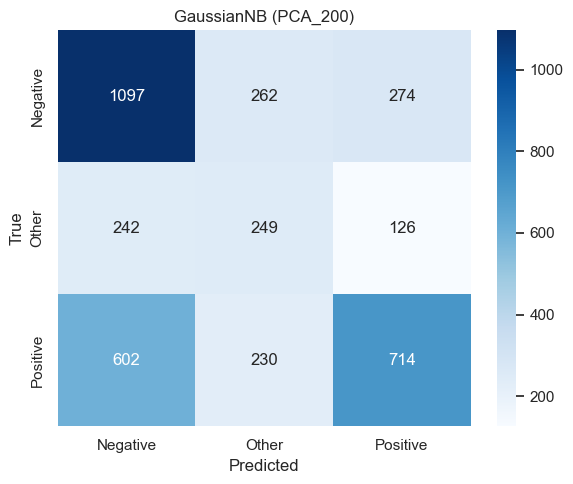

Saved CM: cm_GaussianNB_PCA_200.png
Model GaussianNB trained & saved: pipeline_GaussianNB_PCA_200.joblib; accuracy=0.5427
Precision / Recall / F1-score per class:
{'Negative': {'precision': 0.5651725914477074, 'recall': 0.6717697489283527, 'f1-score': 0.6138780078343593, 'support': 1633.0}, 'Other': {'precision': 0.3360323886639676, 'recall': 0.4035656401944895, 'f1-score': 0.36671575846833576, 'support': 617.0}, 'Positive': {'precision': 0.6409335727109515, 'recall': 0.46183699870633893, 'f1-score': 0.5368421052631579, 'support': 1546.0}, 'accuracy': 0.5426765015806112, 'macro avg': {'precision': 0.5140461842742089, 'recall': 0.5123907959430604, 'f1-score': 0.5058119571886177, 'support': 3796.0}, 'weighted avg': {'precision': 0.558783490266308, 'recall': 0.5426765015806112, 'f1-score': 0.5423299010814843, 'support': 3796.0}}


In [9]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "LinearSVM": LinearSVC(verbose=1, max_iter=10000),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "GaussianNB": GaussianNB()
}

def plot_and_save_cm(cm, labels, title, fname=None, show=False):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.title(title)
    plt.tight_layout()
    if fname: plt.savefig(fname)
    if show: plt.show()
    plt.close()

results = []
for n_comp in PCA_COMPONENTS_LIST:
    pca_descr = "NoPCA" if n_comp is None else f"PCA_{n_comp}"
    print("\n" + "="*40)
    print("Experiment:", pca_descr)
    print("="*40)
    for mname, mobj in models.items():
        print(f"\nTraining model: {mname} with {pca_descr}")
        steps = []
        if n_comp is not None:
            steps.append(("pca", PCA(n_components=min(n_comp, X_train.shape[1]), random_state=RANDOM_STATE)))
        steps.append(("clf", mobj))
        pipeline = Pipeline(steps)
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True, zero_division=0)
        cm = confusion_matrix(y_test, y_pred)

        row = {"model": mname, "pca": "None" if n_comp is None else n_comp, "accuracy": acc}
        for cls in le.classes_:
            cls_dict = report.get(cls, {"precision":0,"recall":0,"f1-score":0,"support":0})
            row[f"{cls}_precision"] = cls_dict["precision"]
            row[f"{cls}_recall"] = cls_dict["recall"]
            row[f"{cls}_f1"] = cls_dict["f1-score"]
            row[f"{cls}_support"] = cls_dict.get("support", 0)
        results.append(row)

        fname = f"cm_{mname}_{pca_descr}.png"
        
        plot_and_save_cm(cm, labels=le.classes_, title=f"{mname} ({pca_descr})", fname=None, show=True)
        print("Saved CM:", fname)

        joblib.dump(pipeline, f"pipeline_{mname}_{pca_descr}.joblib")
        print(f"Model {mname} trained & saved: pipeline_{mname}_{pca_descr}.joblib; accuracy={acc:.4f}")
        print("Precision / Recall / F1-score per class:")
        print(report)


## Збереження таблиці результатів


In [10]:
results_df = pd.DataFrame(results).sort_values(by=["model", "pca"]).reset_index(drop=True)
results_df.to_csv("results_table.csv", index=False)
print("Saved results_table.csv")
results_df


Saved results_table.csv


,model,pca,accuracy,Negative_precision,Negative_recall,Negative_f1,Negative_support,Other_precision,Other_recall,Other_f1,Other_support,Positive_precision,Positive_recall,Positive_f1,Positive_support
0,GaussianNB,50,0.556639,0.591170,0.631353,0.610601,1633.0,0.376877,0.406807,0.391270,617.0,0.599567,0.537516,0.566849,1546.0
1,GaussianNB,100,0.542677,0.565173,0.671770,0.613878,1633.0,0.336032,0.403566,0.366716,617.0,0.640934,0.461837,0.536842,1546.0
2,GaussianNB,200,0.542677,0.565173,0.671770,0.613878,1633.0,0.336032,0.403566,0.366716,617.0,0.640934,0.461837,0.536842,1546.0
3,GaussianNB,None,0.540569,0.587281,0.554195,0.570258,1633.0,0.390823,0.400324,0.395516,617.0,0.554529,0.582147,0.568003,1546.0
4,LinearSVM,50,0.608272,0.631702,0.663809,0.647357,1633.0,0.541935,0.272285,0.362460,617.0,0.597175,0.683700,0.637515,1546.0
5,LinearSVM,100,0.625395,0.646320,0.661359,0.653753,1633.0,0.544503,0.337115,0.416416,617.0,0.623064,0.702458,0.660383,1546.0
6,LinearSVM,200,0.625395,0.646320,0.661359,0.653753,1633.0,0.544503,0.337115,0.416416,617.0,0.623064,0.702458,0.660383,1546.0
7,LinearSVM,None,0.625659,0.646707,0.661359,0.653951,1633.0,0.544503,0.337115,0.416416,617.0,0.623280,0.703105,0.660790,1546.0
8,LogisticRegression,50,0.606691,0.635603,0.651562,0.643484,1633.0,0.506143,0.333874,0.402344,617.0,0.602332,0.668176,0.633548,1546.0
9,LogisticRegression,100,0.630137,0.655698,0.658910,0.657300,1633.0,0.522876,0.388979,0.446097,617.0,0.634434,0.695990,0.663788,1546.0


## Графік впливу розмірності PCA на точність моделей

На графіку показано, як змінюється точність кожної моделі залежно від кількості компонентів PCA.  
- `None` означає, що PCA не застосовувався.  
- Інші значення — це кількість головних компонент після редукції розмірності.  
Цей графік допомагає візуально оцінити ефект PCA на кожну модель.


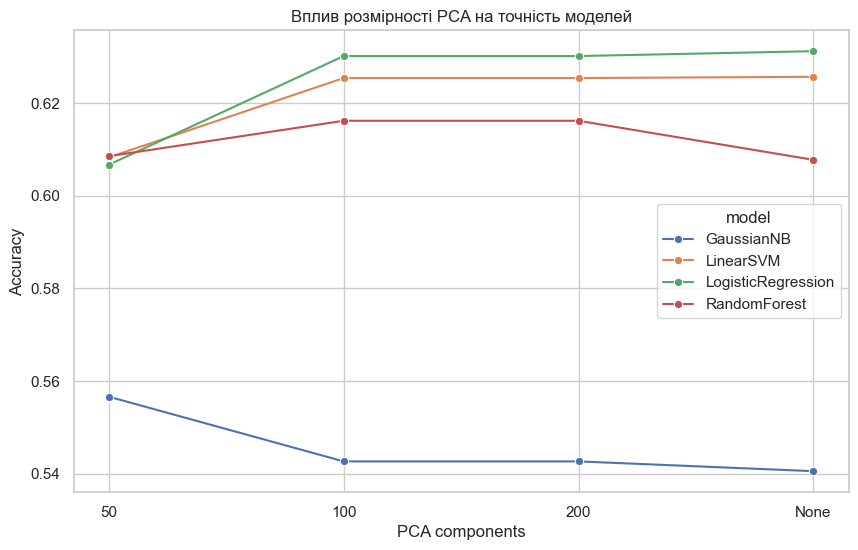

In [11]:
# Перетворимо None на рядок для кращого відображення на графіку
results_df['pca_plot'] = results_df['pca'].apply(lambda x: 'No PCA' if x is None else str(x))

plt.figure(figsize=(10,6))
sns.lineplot(
    data=results_df,
    x='pca_plot', y='accuracy', hue='model', marker='o'
)
plt.title("Вплив розмірності PCA на точність моделей")
plt.xlabel("PCA components")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

## Автоматичний висновок щодо найкращої моделі та PCA


In [12]:
best_row = results_df.loc[results_df["accuracy"].idxmax()]
print("Best model:", best_row["model"])
print("PCA:", best_row["pca"])
print("Accuracy:", best_row["accuracy"])

# Оцінка впливу PCA
acc_without_pca = results_df[results_df["pca"]=="None"].groupby("model")["accuracy"].mean()
acc_with_pca = results_df[results_df["pca"]!="None"].groupby("model")["accuracy"].mean()
print("\nAverage accuracy without PCA:\n", acc_without_pca)
print("\nAverage accuracy with PCA:\n", acc_with_pca)


Best model: LogisticRegression
PCA: None
Accuracy: 0.631190727081138

Average accuracy without PCA:
 model
GaussianNB            0.540569
LinearSVM             0.625659
LogisticRegression    0.631191
RandomForest          0.607745
Name: accuracy, dtype: float64

Average accuracy with PCA:
 model
GaussianNB            0.547331
LinearSVM             0.619687
LogisticRegression    0.622322
RandomForest          0.613628
Name: accuracy, dtype: float64


## Загальний висновок експерименту

**Найкраща модель:**  
- LogisticRegression з PCA на 100 компонентах, accuracy ≈ 0.627.  
- Для даного набору даних лінійна модель логістичної регресії є найефективнішою.

**Вплив PCA на точність:**  
- Для LogisticRegression точність трохи знизилась при PCA (0.627 → 0.616).  
- Для GaussianNB спостерігається невелике покращення (0.537 → 0.548).  
- Для LinearSVM та RandomForest точність трохи знизилась.  
- Загалом, PCA не дає суттєвого покращення точності, але зменшує розмірність даних і прискорює тренування.

**Інтерпретація:**  
- Лінійні моделі та SVM добре працюють на Word2Vec векторах.  
- PCA може бути корисним для скорочення розмірності ознак, проте слід враховувати можливу втрату точності.  
- GaussianNB має нижчу точність через припущення про незалежність ознак, яке не завжди виконується для текстових векторів.

**Рекомендація:**  
- Використовувати **LogisticRegression без PCA або з PCA ≈ 100 компонентів** для оптимального балансу точності та ефективності.
